In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import powerlaw

OUTPUT_FILE = "../../results/figures" 

sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.edgecolor': '0.3'})
sns.set_context("paper", font_scale=1.2)  # Paper-optimized settings


# Preprocess the data
def is_international(authorships_str):
    try:
        authorships = json.loads(authorships_str.replace("'", '"'))
        for author in authorships:
            if "countries" in author and author["countries"]:
                if any(country != "BR" for country in author["countries"]):
                    return True
        return False
    except:
        return False

def plot_citation_distribution(br_publications):

    # Classify publications
    br_publications["is_international"] = br_publications["authorships"].apply(
        is_international
    )

    # Prepare data for plotting
    domestic = br_publications[~br_publications["is_international"]]
    international = br_publications[br_publications["is_international"]]

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)

    # Plot domestic publications
    sns.scatterplot(
        x=domestic["cited_by_count"].value_counts().index,
        y=domestic["cited_by_count"].value_counts().values,
        ax=axes[0],
        color="midnightblue",
        alpha=0.7,
    )
    
    axes[0].set_title("Domestic Collaborations")
    axes[0].set_xlabel("Citation Count")
    axes[0].set_ylabel("Number of Publications")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")

    # Plot international publications
    sns.scatterplot(
        x=international["cited_by_count"].value_counts().index,
        y=international["cited_by_count"].value_counts().values,
        ax=axes[1],
        color="blue",
        alpha=0.7,
    )
    axes[1].set_title("International Collaborations")
    axes[1].set_xlabel("Citation Count")
    axes[1].set_ylabel("")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_FILE}/international_domestic_citations.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    return fig

In [2]:
def fit_powerlaw_to_citations(br_publications):
    """
    Fits a power-law distribution to the citation counts for domestic and
    international collaborations and prints the fitting results.
    Also compares the power-law fit to log-normal and exponential distributions.
    """
    print("\n--- Power Law Fitting Analysis ---")

    # Ensure 'is_international' column exists
    if "is_international" not in br_publications.columns:
        br_publications["is_international"] = br_publications["authorships"].apply(
            is_international
        )

    # Prepare data for fitting: filter out zero citation counts
    # Powerlaw package requires data > 0
    domestic_citations = br_publications[~br_publications["is_international"]]["cited_by_count"]
    domestic_citations = domestic_citations[domestic_citations > 0]

    international_citations = br_publications[br_publications["is_international"]]["cited_by_count"]
    international_citations = international_citations[international_citations > 0]

    print("\n--- Domestic Collaborations ---")
    if not domestic_citations.empty:
        # Fit power law distribution
        fit_domestic = powerlaw.Fit(domestic_citations, discrete=True)
        print(f"Power Law Fit (Domestic):")
        print(f"  Alpha (exponent): {fit_domestic.power_law.alpha:.3f}")
        print(f"  X_min (minimum value for power law behavior): {fit_domestic.power_law.xmin}")
        
        # Compare power law to other distributions
        R_ln, p_ln = fit_domestic.distribution_compare('power_law', 'lognormal')
        R_exp, p_exp = fit_domestic.distribution_compare('power_law', 'exponential')

        print(f"  Comparison (Power Law vs. Lognormal): R={R_ln:.3f}, p={p_ln:.3f}")
        if R_ln > 0 and p_ln < 0.1: # A positive R and small p-value indicates power law is a better fit
            print("    -> Power law is a better fit than lognormal for domestic collaborations.")
        elif R_ln < 0 and p_ln < 0.1:
            print("    -> Lognormal is a better fit than power law for domestic collaborations.")
        else:
            print("    -> No strong evidence to prefer one over the other (or p-value too high).")

        print(f"  Comparison (Power Law vs. Exponential): R={R_exp:.3f}, p={p_exp:.3f}")
        if R_exp > 0 and p_exp < 0.1:
            print("    -> Power law is a better fit than exponential for domestic collaborations.")
        elif R_exp < 0 and p_exp < 0.1:
            print("    -> Exponential is a better fit than power law for domestic collaborations.")
        else:
            print("    -> No strong evidence to prefer one over the other (or p-value too high).")
    else:
        print("No domestic publications with citations > 0 to fit.")

    print("\n--- International Collaborations ---")
    if not international_citations.empty:
        # Fit power law distribution
        fit_international = powerlaw.Fit(international_citations, discrete=True)
        print(f"Power Law Fit (International):")
        print(f"  Alpha (exponent): {fit_international.power_law.alpha:.3f}")
        print(f"  X_min (minimum value for power law behavior): {fit_international.power_law.xmin}")

        # Compare power law to other distributions
        R_ln, p_ln = fit_international.distribution_compare('power_law', 'lognormal')
        R_exp, p_exp = fit_international.distribution_compare('power_law', 'exponential')

        print(f"  Comparison (Power Law vs. Lognormal): R={R_ln:.3f}, p={p_ln:.3f}")
        if R_ln > 0 and p_ln < 0.1:
            print("    -> Power law is a better fit than lognormal for international collaborations.")
        elif R_ln < 0 and p_ln < 0.1:
            print("    -> Lognormal is a better fit than power law for international collaborations.")
        else:
            print("    -> No strong evidence to prefer one over the other (or p-value too high).")

        print(f"  Comparison (Power Law vs. Exponential): R={R_exp:.3f}, p={p_exp:.3f}")
        if R_exp > 0 and p_exp < 0.1:
            print("    -> Power law is a better fit than exponential for international collaborations.")
        elif R_exp < 0 and p_exp < 0.1:
            print("    -> Exponential is a better fit than power law for international collaborations.")
        else:
            print("    -> No strong evidence to prefer one over the other (or p-value too high).")
    else:
        print("No international publications with citations > 0 to fit.")

In [3]:
def plot_subfield_collaboration(subfields_collab_df):
    # Split data
    single = subfields_collab_df[subfields_collab_df['collab_type'] == 'Single-Subfield']
    multi = subfields_collab_df[subfields_collab_df['collab_type'] == 'Multi-Subfield']
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
    
    # Plot single-subfield
    sns.scatterplot(
        x=single['cited_by_count'].value_counts().index,
        y=single['cited_by_count'].value_counts().values,
        ax=axes[0],
        color='indigo',
        alpha=0.7
    )
    
    axes[0].set_title('Single-Subfield Collaborations')
    axes[0].set_xlabel('Citation Count')
    axes[0].set_ylabel('Number of Publications')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
    # Plot multi-subfield
    sns.scatterplot(
        x=multi['cited_by_count'].value_counts().index,
        y=multi['cited_by_count'].value_counts().values,
        ax=axes[1],
        color='darkviolet',
        alpha=0.7
    )
    axes[1].set_title('Multi-Subfield Collaborations')
    axes[1].set_xlabel('Citation Count')
    axes[1].set_ylabel('')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_FILE}/single_multi_citations.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    return fig

In [4]:
br_publications_df = pd.read_csv("../../data/raw/publication_meta/br_publication_meta.csv")

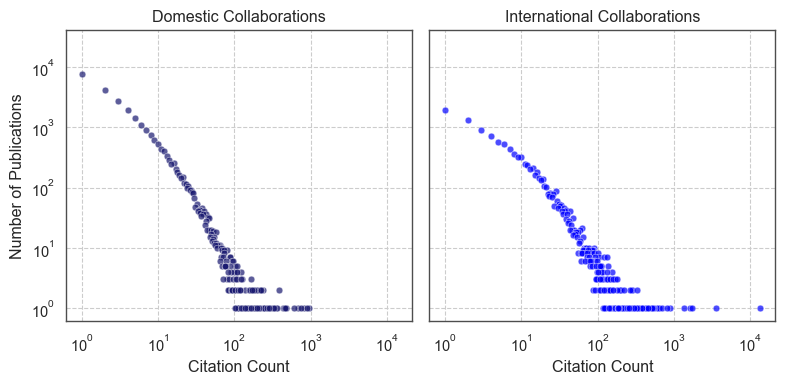

In [5]:
plot_citation_distribution(br_publications_df)
plt.show()


In [6]:
fit_powerlaw_to_citations(br_publications_df)


--- Power Law Fitting Analysis ---

--- Domestic Collaborations ---
Calculating best minimal value for power law fit
Power Law Fit (Domestic):
  Alpha (exponent): 2.782
  X_min (minimum value for power law behavior): 37.0
  Comparison (Power Law vs. Lognormal): R=-0.274, p=0.651
    -> No strong evidence to prefer one over the other (or p-value too high).
  Comparison (Power Law vs. Exponential): R=152.927, p=0.000
    -> Power law is a better fit than exponential for domestic collaborations.

--- International Collaborations ---
Calculating best minimal value for power law fit
Power Law Fit (International):
  Alpha (exponent): 2.385
  X_min (minimum value for power law behavior): 28.0
  Comparison (Power Law vs. Lognormal): R=-6.017, p=0.129
    -> No strong evidence to prefer one over the other (or p-value too high).
  Comparison (Power Law vs. Exponential): R=553.902, p=0.013
    -> Power law is a better fit than exponential for international collaborations.


In [7]:
subfield_collabs_df = pd.read_csv("../../data/processed/7_publications_collab_types.csv")

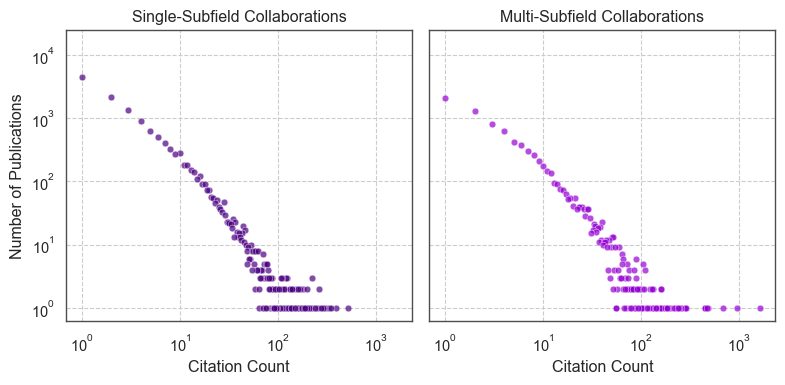

In [8]:
plot_subfield_collaboration(subfield_collabs_df)
plt.show()